In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 1, 0, 1, 0, 1], dtype=float)

In [3]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        if i == 1:
            A[i - 1] = 0
        else:
            A[i - 1] = h[i - 1]
        B[i - 1] = 2 * (h[i - 1] + h[i])
        if i == n - 2:
            C[i - 1] = 0
        else:
            C[i - 1] = h[i]
        D[i - 1] = 6 * (((y[i + 1] - y[i]) / h[i]) - ((y[i] - y[i - 1])/ h[i - 1]))
    return A, B, C, D

In [10]:
A, B, C, D = setup_tridiagonal_matrix(x, y)

In [11]:
def thomas_algorithm(A, B, C, D):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    A: sub-diagonal elements (length n-1)
    B: main diagonal elements (length n)
    C: super-diagonal elements (length n-1)
    D: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(B)
    # Forward elimination
    for i in range(1, n):
        w = A[i-1] / B[i-1]
        B[i] = B[i] - w * C[i-1]
        D[i] = D[i] - w * D[i-1]# Back substitution
        x = np.zeros(n)
        x[-1] = D[-1] / B[-1]
    for i in range(n-2, -1, -1):
        x[i] = (D[i] - C[i] * x[i+1]) / B[i]
    return x
    


In [12]:
M_int = thomas_algorithm(A, B, C, D)
M = np.zeros(len(x))   
M[1:-1] = M_int

In [7]:
def evaluate_spline(x, y, M, x_eval):

    n = len(x)
    h = np.diff(x)
    y_eval = np.zeros_like(x_eval, dtype=float)
 
    for k, xv in enumerate(x_eval):
        # Find the interval [x[i], x[i+1]] that contains xv
        i = np.searchsorted(x, xv, side='right') - 1
        # Clamp to valid interval range
        i = int(np.clip(i, 0, n - 2))
 
        dx = xv - x[i]
        hi = h[i]
 
        
        a_coef = (M[i + 1] - M[i]) / (6 * hi)
        b_coef = M[i] / 2
        c_coef = (y[i + 1] - y[i]) / hi - hi * (2 * M[i] + M[i + 1]) / 6
        d_coef = y[i]
 
        y_eval[k] = a_coef * dx**3 + b_coef * dx**2 + c_coef * dx + d_coef
 
    return y_eval
 
x_fine = np.linspace(x[0], x[-1], 500)
y_fine = evaluate_spline(x, y, M, x_fine)
 


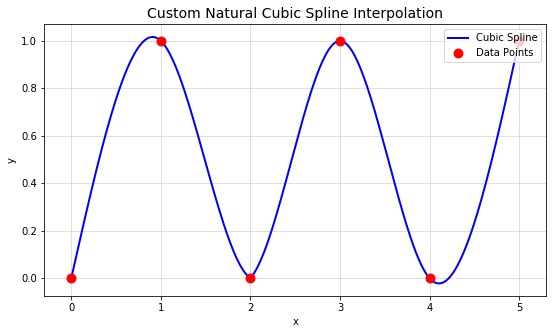

In [15]:
plt.figure(figsize=(9, 5))
plt.plot(x_fine, y_fine, color='b', linewidth=2, label='Cubic Spline')
plt.scatter(x, y, color='r', zorder=5, s=80, label='Data Points')
plt.title('Custom Natural Cubic Spline Interpolation', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.5)

plt.show()

In [9]:
"Asked about the mismatched and how the points arent on the peak but claude says that was normal"

'Asked about the mismatched and how the points arent on the peak but claude says that was normal'